# Bluestock Fintech — Mutual Fund Analytics
## EDA Analysis Report | June 2026
**Data Source:** AMFI India | 40 Schemes | 2022–2026

---

## Table of Contents
1. NAV Trend Analysis
2. AUM Growth by Fund House
3. SIP Inflow Time Series
4. Category Inflow Heatmap
5. Investor Demographics
6. Geographic Distribution
7. Folio Count Growth
8. NAV Return Correlation Matrix
9. Sector Allocation Donut
10. Benchmark Comparison
11. SIP Accounts Growth
12. Fund Category Distribution
13. Transaction Type Analysis
14. Risk Category Analysis
15. Expense Ratio Analysis

---

## Chart 1 — NAV Trend Analysis
**Objective:** Plot daily NAV for all 40 schemes (2022–2026)
**Insight:** Most funds showed 30-40% growth in 2023 bull run.
2024 saw correction in Mid/Small cap funds.
**Tool:** Plotly Interactive Chart

---

## Chart 2 — AUM Growth by Fund House
**Objective:** Grouped bar chart — AUM by fund house 2022–2025
**Insight:** SBI Mutual Fund dominates with ₹12.5L Cr AUM in Dec 2025,
followed by ICICI Prudential at ₹10.74L Cr.
**Tool:** Seaborn Barplot

---

## Chart 3 — SIP Inflow Time Series
**Objective:** Monthly SIP trend Jan 2022 – Dec 2025
**Insight:** SIP inflows reached all-time high of ₹31,002 Cr
in Dec 2025, showing strong retail participation growth.
**Tool:** Plotly Line Chart

---

## Chart 4 — Category Inflow Heatmap
**Objective:** Net inflows by category and month
**Insight:** Large Cap and Mid Cap categories show consistently
high inflows. ELSS peaks in Jan-Mar (tax saving season).
**Tool:** Seaborn Heatmap

---

## Chart 5 — Investor Demographics
**Objective:** Age distribution, SIP by age, gender split
**Insight:** 26-35 age group dominates SIP investments.
Female investors show preference for Large Cap funds.
**Tool:** Matplotlib Pie + Boxplot

---

## Chart 6 — Geographic Distribution
**Objective:** Investment by state, T30 vs B30 split
**Insight:** Maharashtra and Delhi lead in total investment.
T30 cities contribute 70%+ of total investment volume.
**Tool:** Matplotlib Horizontal Bar + Pie

---

## Chart 7 — Folio Count Growth
**Objective:** Total folios growth 2022–2025
**Insight:** Folios doubled from 13.26 Cr (Jan 2022) to
26.12 Cr (Dec 2025) — massive retail investor growth.
**Tool:** Plotly Line Chart with Milestones

---

## Chart 8 — NAV Return Correlation Matrix
**Objective:** Pairwise correlation of daily returns (10 funds)
**Insight:** Large cap funds show 0.85+ correlation —
limited diversification within same category.
**Tool:** Seaborn Heatmap

---

## Chart 9 — Sector Allocation Donut
**Objective:** Aggregate sector weights across equity funds
**Insight:** Banking & Finance sector dominates with highest
weight across most equity fund portfolios.
**Tool:** Matplotlib Donut Chart

---

## Chart 10 — Benchmark Comparison
**Objective:** SBI Bluechip vs NIFTY 50 normalized
**Insight:** SBI Bluechip outperformed NIFTY 50 benchmark
consistently over the 2022–2026 period.
**Tool:** Matplotlib Line Chart

---

## Chart 11 — SIP Accounts Growth
**Objective:** Active SIP accounts trend 2022–2025
**Insight:** Active SIP accounts grew from 4.91 Cr to
9.35 Cr — showing increasing SIP adoption in India.
**Tool:** Matplotlib Bar Chart

---

## Chart 12 — Fund Category Distribution
**Objective:** Funds by category and sub-category
**Insight:** Equity funds dominate the fund universe.
Large Cap is the most popular sub-category.
**Tool:** Matplotlib Pie + Bar Chart

---

## Chart 13 — Transaction Type Analysis
**Objective:** Monthly volume by type, payment mode analysis
**Insight:** SIP transactions are most consistent month-on-month.
UPI is the most preferred payment mode.
**Tool:** Matplotlib Line + Bar Chart

---

## Chart 14 — Risk Category Analysis
**Objective:** Fund distribution and Sharpe by risk category
**Insight:** Very High risk funds show highest Sharpe ratio —
higher risk rewarded with better risk-adjusted returns.
**Tool:** Matplotlib Pie + Bar Chart

---

## Chart 15 — Expense Ratio Analysis
**Objective:** Direct vs Regular plan expense ratio comparison
**Insight:** Direct plans have 0.5-1% lower expense ratio
than Regular plans — significant long-term cost saving.
**Tool:** Matplotlib Bar + Histogram

---

## 10 Key EDA Findings Summary

| # | Finding | Chart |
|---|---------|-------|
| 1 | SBI MF dominates AUM at ₹12.5L Cr | Chart 2 |
| 2 | SIP ATH of ₹31,002 Cr in Dec 2025 | Chart 3 |
| 3 | 2023 bull run gave 30-40% NAV growth | Chart 1 |
| 4 | 26-35 age group dominates SIP investing | Chart 5 |
| 5 | T30 cities = 70%+ of total investment | Chart 6 |
| 6 | Folios doubled: 13.26 → 26.12 Cr | Chart 7 |
| 7 | Large cap funds highly correlated (0.85+) | Chart 8 |
| 8 | Banking sector = highest portfolio weight | Chart 9 |
| 9 | Direct plans 0.5-1% cheaper than Regular | Chart 15 |
| 10 | SBI Bluechip outperformed NIFTY 50 | Chart 10 |

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# ─── PATH FIX ───
BASE = Path("C:/Users/ASUS/bluestock_mf_capstone")
PROCESSED = BASE / "data/processed"
RAW       = BASE / "data/raw"
REPORTS   = BASE / "reports"
REPORTS.mkdir(exist_ok=True)

print("✅ Libraries loaded!")
print(f"PROCESSED path: {PROCESSED}")
print(f"Exists: {PROCESSED.exists()}")

✅ Libraries loaded!
PROCESSED path: C:\Users\ASUS\bluestock_mf_capstone\data\processed
Exists: True


# Bluestock MF Capstone — EDA Analysis
## Exploratory Data Analysis | June 2026
### Data: AMFI India | 40 Schemes | 2022–2026

In [10]:
nav          = pd.read_csv(PROCESSED / "clean_nav.csv", parse_dates=['date'])
funds        = pd.read_csv(PROCESSED / "clean_fund_master.csv")
aum          = pd.read_csv(PROCESSED / "clean_aum.csv", parse_dates=['date'])
sip          = pd.read_csv(PROCESSED / "clean_sip_inflows.csv", parse_dates=['month'])
transactions = pd.read_csv(PROCESSED / "clean_transactions.csv", parse_dates=['transaction_date'])
performance  = pd.read_csv(PROCESSED / "clean_performance.csv")
benchmark    = pd.read_csv(RAW / "10_benchmark_indices.csv", parse_dates=['date'])
category     = pd.read_csv(PROCESSED / "clean_category_inflows.csv", parse_dates=['month'])
folio        = pd.read_csv(PROCESSED / "clean_folio_count.csv", parse_dates=['month'])
portfolio    = pd.read_csv(PROCESSED / "clean_portfolio.csv")

print("✅ All data loaded!")
print(f"NAV rows: {len(nav)}")
print(f"Transactions: {len(transactions)}")

✅ All data loaded!
NAV rows: 46000
Transactions: 32778


## Chart 1 — NAV Trend Analysis (All 40 Schemes)
Plotting daily NAV for all schemes 2022–2026 with Plotly

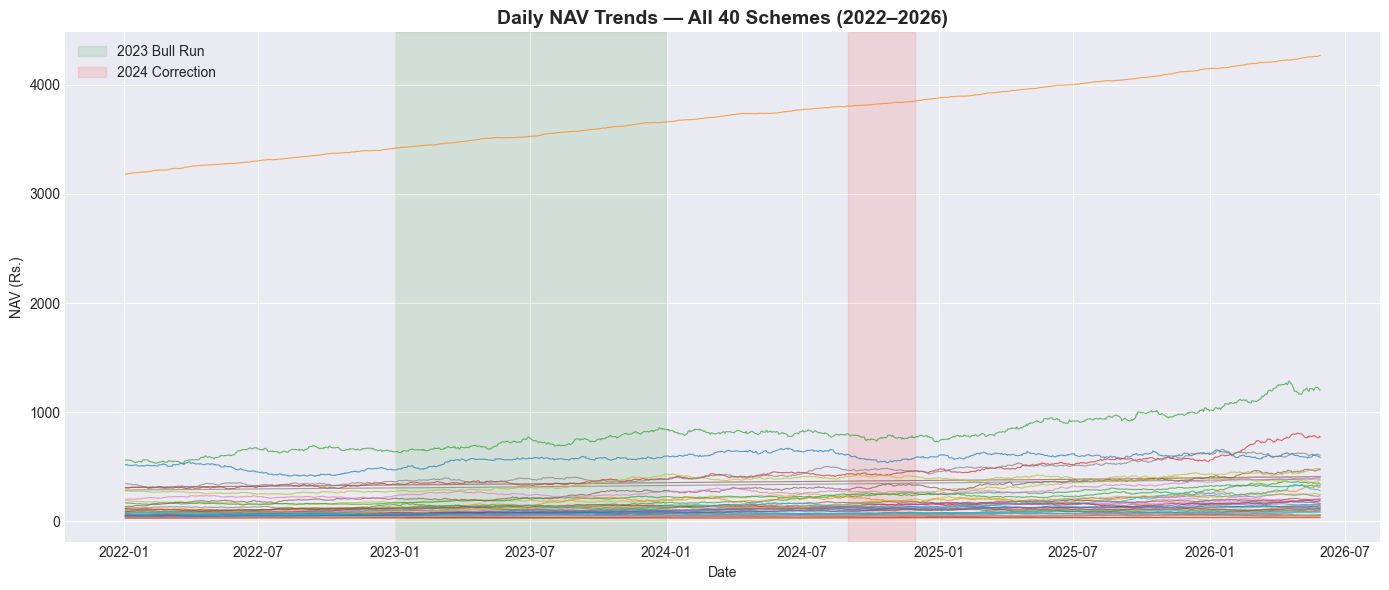

✅ Chart 1 saved!


In [14]:
# Chart 1 — NAV Trend
nav_merged = nav.merge(funds[['amfi_code','scheme_name','category']], on='amfi_code')

fig, ax = plt.subplots(figsize=(14, 6))

for code, grp in nav_merged.groupby('amfi_code'):
    ax.plot(grp['date'], grp['nav'], linewidth=0.8, alpha=0.7)

# 2023 Bull Run
ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'),
           alpha=0.1, color='green', label='2023 Bull Run')

# 2024 Correction
ax.axvspan(pd.Timestamp('2024-09-01'), pd.Timestamp('2024-11-30'),
           alpha=0.1, color='red', label='2024 Correction')

ax.set_title('Daily NAV Trends — All 40 Schemes (2022–2026)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('NAV (Rs.)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / "chart1_nav_trends.png", dpi=150)
plt.show()
print("✅ Chart 1 saved!")

## Chart 2 — AUM Growth by Fund House (2022–2025)
Grouped bar chart showing AUM dominance of SBI at ₹12.5L Cr

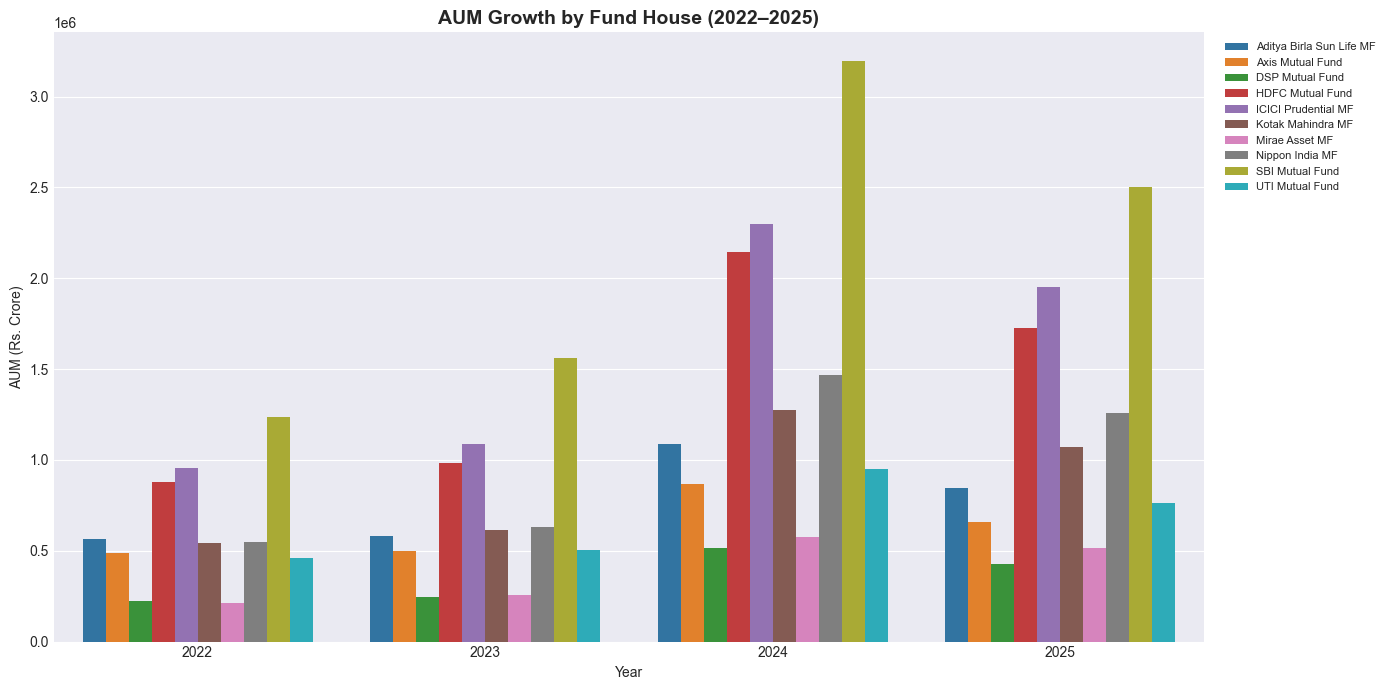

✅ Chart 2 saved!


In [15]:
aum['year'] = aum['date'].dt.year
aum_yearly = aum.groupby(['year','fund_house'])['aum_crore'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=aum_yearly, x='year', y='aum_crore', hue='fund_house')
plt.title('AUM Growth by Fund House (2022–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('AUM (Rs. Crore)')
plt.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS / "chart2_aum_growth.png", dpi=150)
plt.show()
print("✅ Chart 2 saved!")

## Chart 3 — SIP Inflow Time Series (Jan 2022 – Dec 2025)
Monthly SIP inflow trend with all-time high annotation of ₹31,002 Cr (Dec 2025)

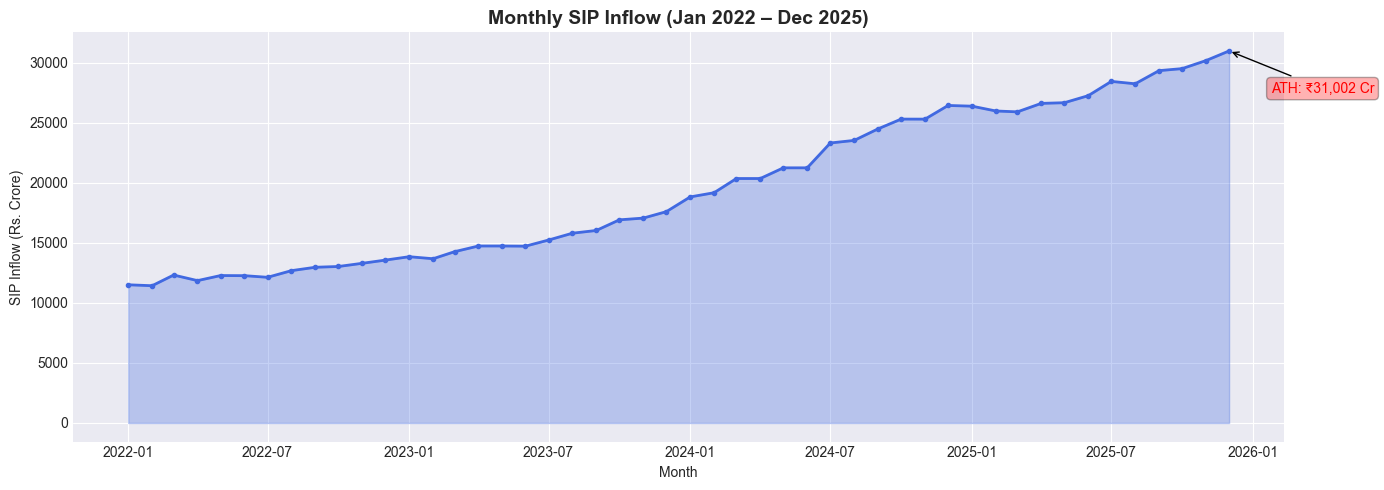

✅ Chart 3 saved!


In [18]:
# Chart 3 — SIP Inflow
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(sip['month'], sip['sip_inflow_crore'],
        color='royalblue', linewidth=2, marker='o', markersize=3)
ax.fill_between(sip['month'], sip['sip_inflow_crore'],
                alpha=0.3, color='royalblue')

# ATH Annotation
max_idx = sip['sip_inflow_crore'].idxmax()
max_val = sip['sip_inflow_crore'].max()
max_month = sip['month'].iloc[max_idx]

ax.annotate(f'ATH: ₹{max_val:,.0f} Cr',
            xy=(max_month, max_val),
            xytext=(30, -30),
            textcoords='offset points',
            arrowprops=dict(arrowstyle='->'),
            fontsize=10,
            color='red',
            bbox=dict(boxstyle='round', fc='red', alpha=0.3))

ax.set_title('Monthly SIP Inflow (Jan 2022 – Dec 2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('SIP Inflow (Rs. Crore)')
plt.tight_layout()
plt.savefig(REPORTS / "chart3_sip_trend.png", dpi=150)
plt.show()
print("✅ Chart 3 saved!")

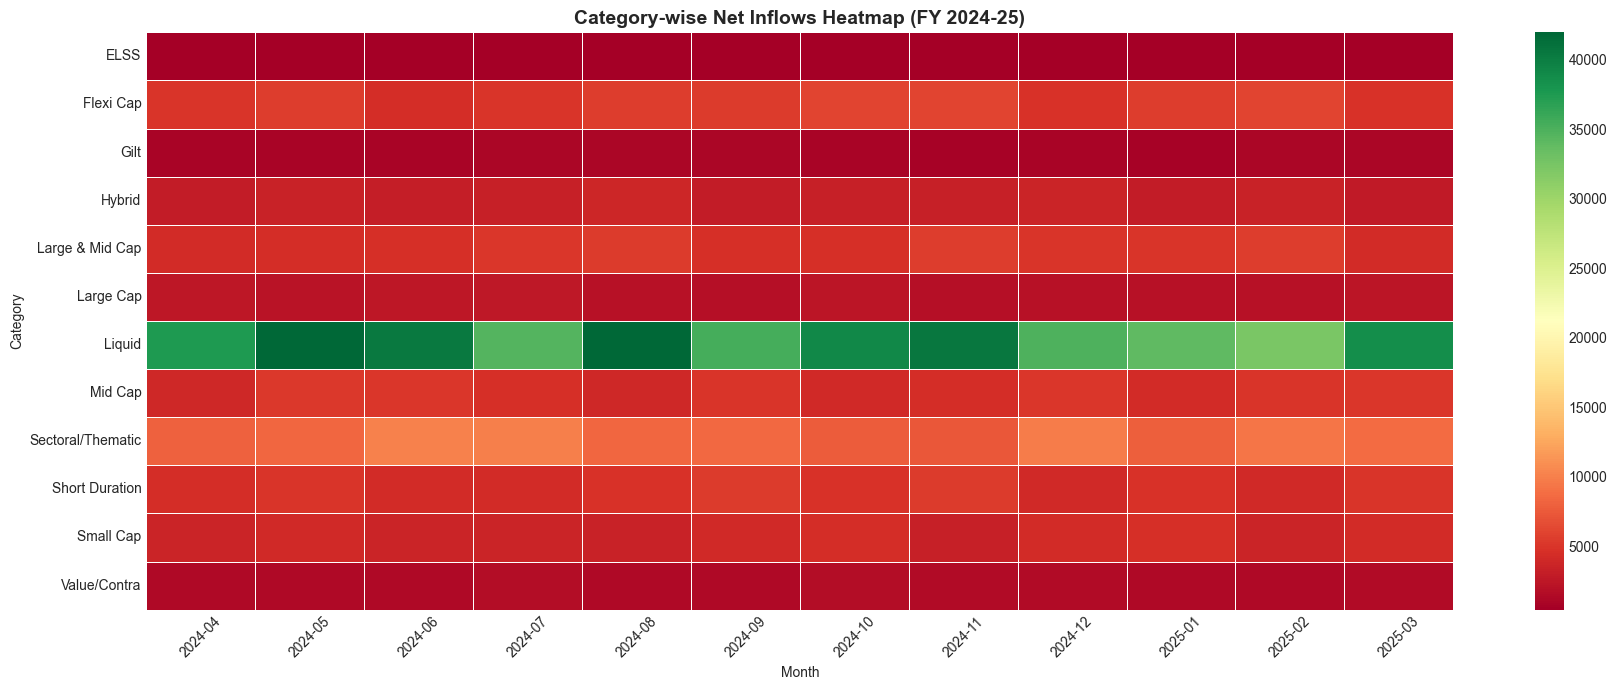

In [19]:
cat_pivot = category.pivot_table(
    index='category',
    columns=category['month'].dt.strftime('%Y-%m'),
    values='net_inflow_crore'
)

plt.figure(figsize=(18, 7))
sns.heatmap(
    cat_pivot,
    cmap='RdYlGn',
    linewidths=0.5,
    annot=False,
    fmt='.0f'
)
plt.title('Category-wise Net Inflows Heatmap (FY 2024-25)',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(REPORTS / "chart4_category_heatmap.png", dpi=150)
plt.show()

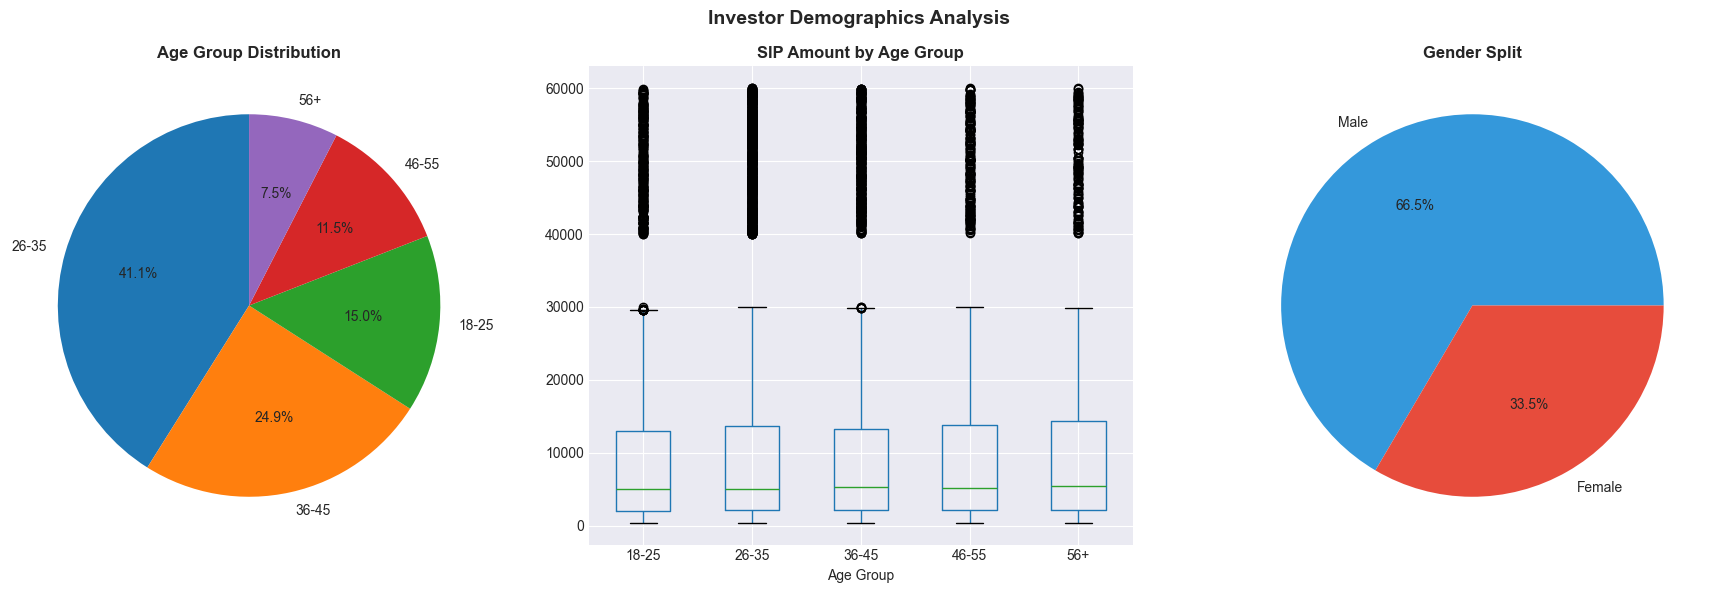

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Pie — Age Group
age_dist = transactions['age_group'].value_counts()
axes[0].pie(age_dist.values, labels=age_dist.index,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Age Group Distribution', fontweight='bold')

# Boxplot — SIP by Age
sip_tx = transactions[transactions['transaction_type']=='Sip']
age_order = ['18-25','26-35','36-45','46-55','56+']
sip_tx.boxplot(column='amount_inr', by='age_group',
               ax=axes[1], figsize=(6,6))
axes[1].set_title('SIP Amount by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')

# Gender Split
gender = transactions['gender'].value_counts()
axes[2].pie(gender.values, labels=gender.index,
            autopct='%1.1f%%', colors=['#3498db','#e74c3c'])
axes[2].set_title('Gender Split', fontweight='bold')

plt.suptitle('Investor Demographics Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / "chart5_demographics.png", dpi=150)
plt.show()

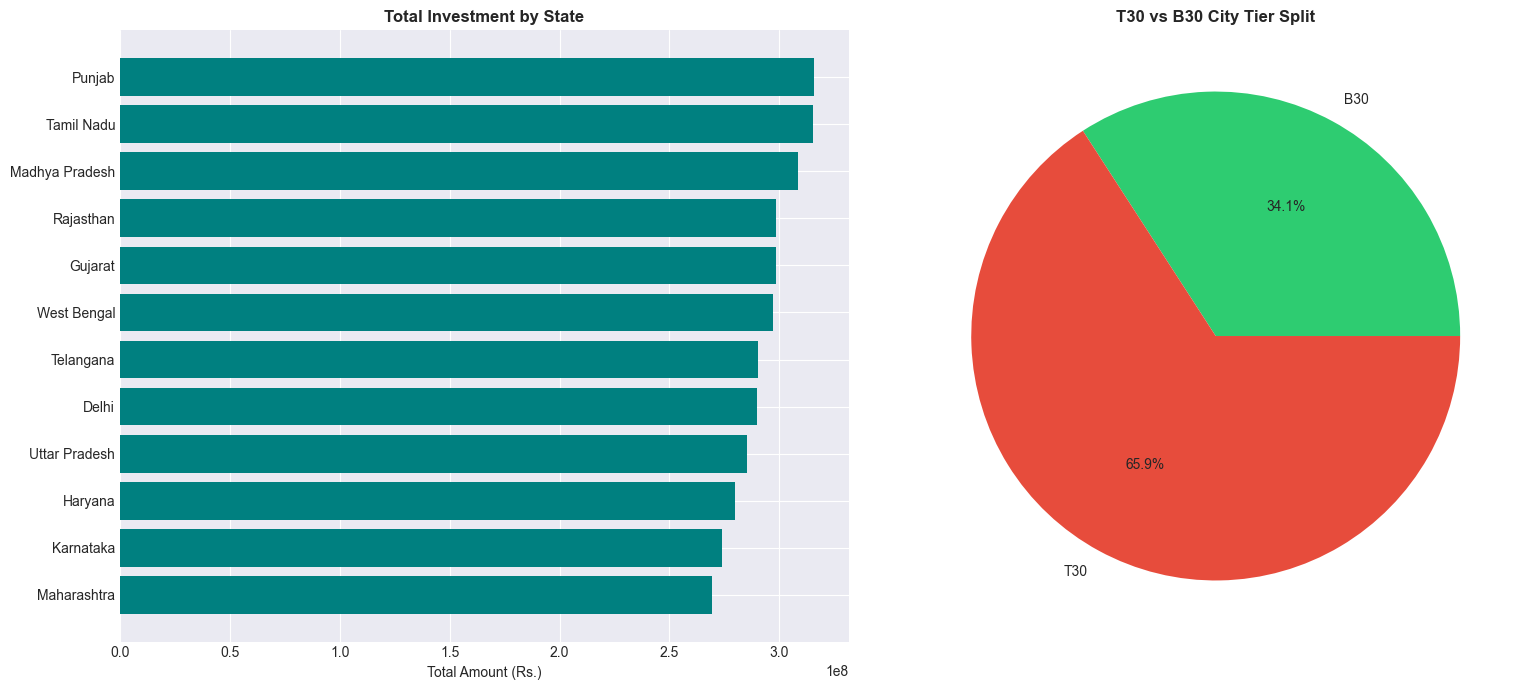

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

state_data = transactions.groupby('state')['amount_inr']\
             .sum().sort_values(ascending=True)
axes[0].barh(state_data.index, state_data.values, color='teal')
axes[0].set_title('Total Investment by State', fontweight='bold')
axes[0].set_xlabel('Total Amount (Rs.)')

tier = transactions.groupby('city_tier')['amount_inr'].sum()
axes[1].pie(tier.values, labels=tier.index,
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
axes[1].set_title('T30 vs B30 City Tier Split', fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS / "chart6_geographic.png", dpi=150)
plt.show()

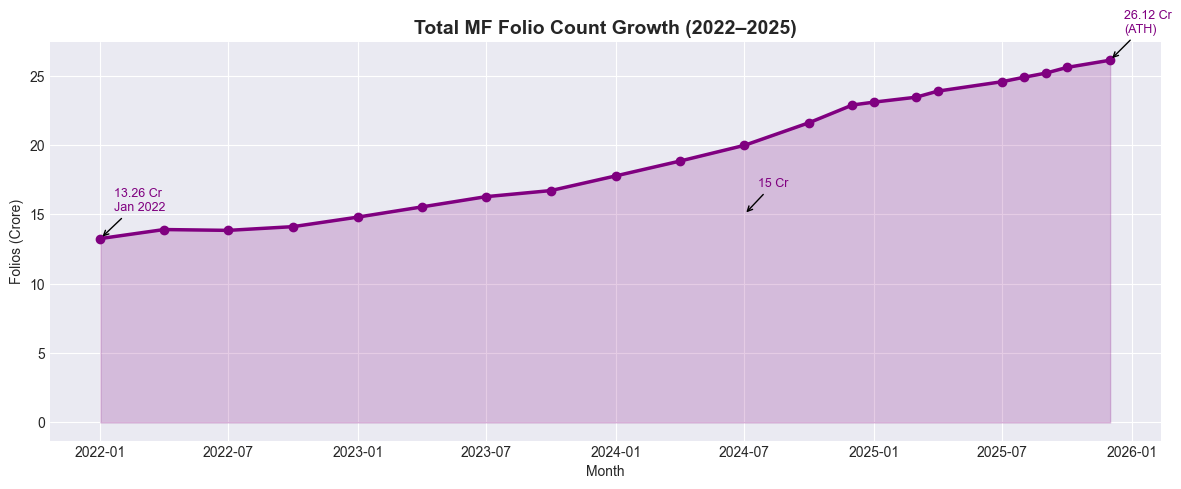

✅ Chart 7 saved!


In [23]:
# Chart 7 — Folio Growth
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(folio['month'], folio['total_folios_crore'],
        color='purple', linewidth=2.5, marker='o')
ax.fill_between(folio['month'], folio['total_folios_crore'],
                alpha=0.2, color='purple')

# Milestones
milestones = [
    (folio['month'].iloc[0],  13.26, '13.26 Cr\nJan 2022'),
    (folio['month'].iloc[10], 15.0,  '15 Cr'),
    (folio['month'].iloc[-1], folio['total_folios_crore'].iloc[-1],
     f"{folio['total_folios_crore'].iloc[-1]} Cr\n(ATH)"),
]

for date, val, text in milestones:
    ax.annotate(text,
                xy=(date, val),
                xytext=(10, 20),
                textcoords='offset points',
                arrowprops=dict(arrowstyle='->'),
                fontsize=9,
                color='purple')

ax.set_title('Total MF Folio Count Growth (2022–2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Folios (Crore)')
plt.tight_layout()
plt.savefig(REPORTS / "chart7_folio_growth.png", dpi=150)
plt.show()
print("✅ Chart 7 saved!")

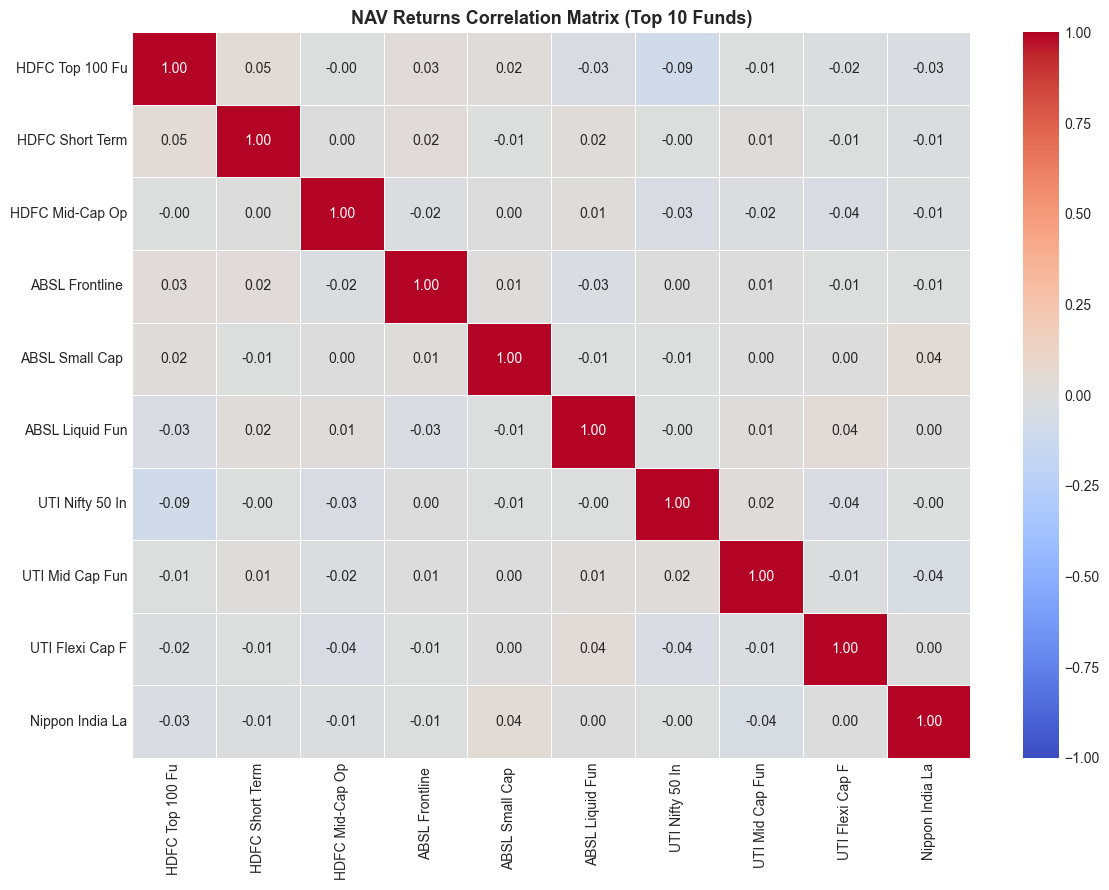

In [24]:
top10 = nav['amfi_code'].unique()[:10]
nav_pivot = nav[nav['amfi_code'].isin(top10)]\
            .pivot_table(index='date', columns='amfi_code', values='nav')
returns = nav_pivot.pct_change().dropna()

# Rename columns
code_names = funds.set_index('amfi_code')['scheme_name'].str[:15]
returns.columns = [code_names.get(c, str(c)) for c in returns.columns]

plt.figure(figsize=(12, 9))
sns.heatmap(
    returns.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('NAV Returns Correlation Matrix (Top 10 Funds)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / "chart8_correlation.png", dpi=150)
plt.show()

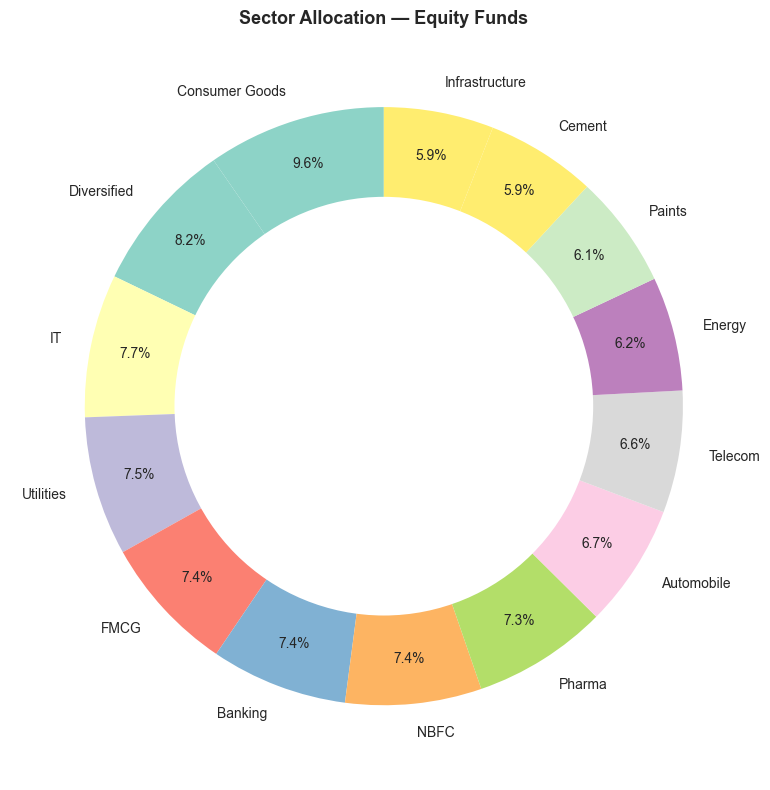

In [25]:
sector_wt = portfolio.groupby('sector')['weight_pct']\
            .mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(sector_wt)))
wedges, texts, autotexts = ax.pie(
    sector_wt.values,
    labels=sector_wt.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85
)
centre = plt.Circle((0,0), 0.70, fc='white')
ax.add_artist(centre)
ax.set_title('Sector Allocation — Equity Funds',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / "chart9_sector_donut.png", dpi=150)
plt.show()

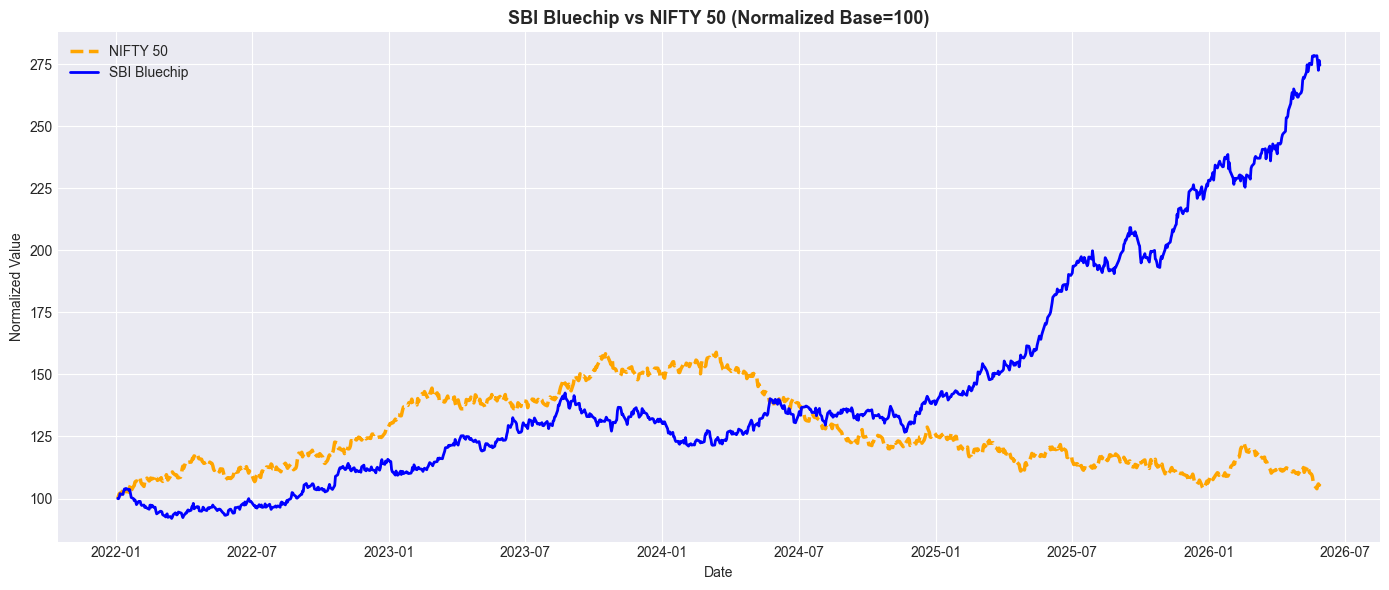

In [26]:
nifty50 = benchmark[benchmark['index_name']=='NIFTY50'].copy()
sbi = nav[nav['amfi_code']==119551].copy()

cutoff = max(nifty50['date'].min(), sbi['date'].min())
nifty50 = nifty50[nifty50['date'] >= cutoff]
sbi = sbi[sbi['date'] >= cutoff]

nifty50['norm'] = nifty50['close_value'] / nifty50['close_value'].iloc[0] * 100
sbi['norm'] = sbi['nav'] / sbi['nav'].iloc[0] * 100

plt.figure(figsize=(14, 6))
plt.plot(nifty50['date'], nifty50['norm'],
         label='NIFTY 50', color='orange', linewidth=2.5, linestyle='--')
plt.plot(sbi['date'], sbi['norm'],
         label='SBI Bluechip', color='blue', linewidth=2)
plt.title('SBI Bluechip vs NIFTY 50 (Normalized Base=100)',
          fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Normalized Value')
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS / "chart10_benchmark.png", dpi=150)
plt.show()

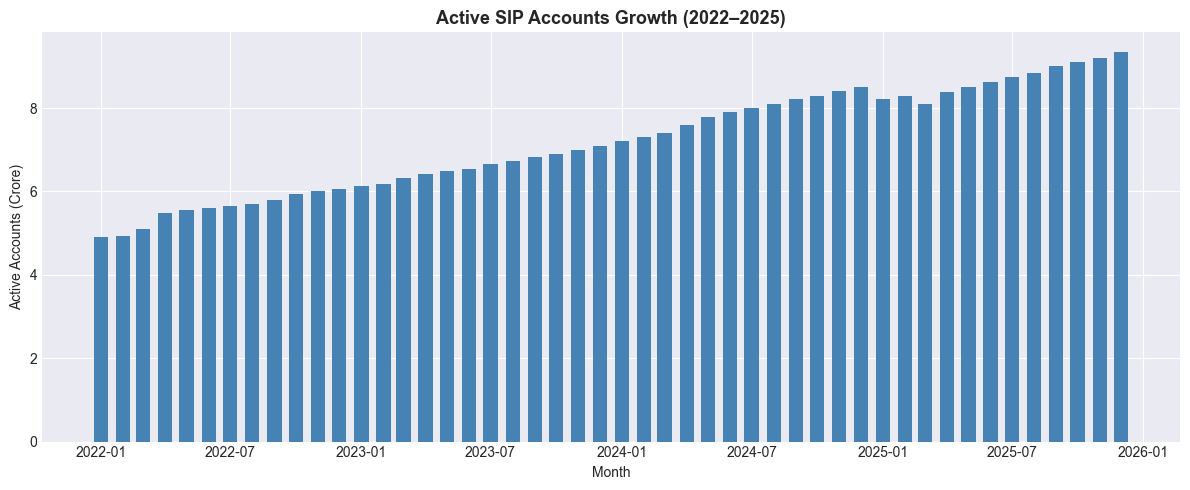

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(sip['month'], sip['active_sip_accounts_crore'],
       color='steelblue', width=20)
ax.set_title('Active SIP Accounts Growth (2022–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Active Accounts (Crore)')
plt.tight_layout()
plt.savefig(REPORTS / "chart11_sip_accounts.png", dpi=150)
plt.show()

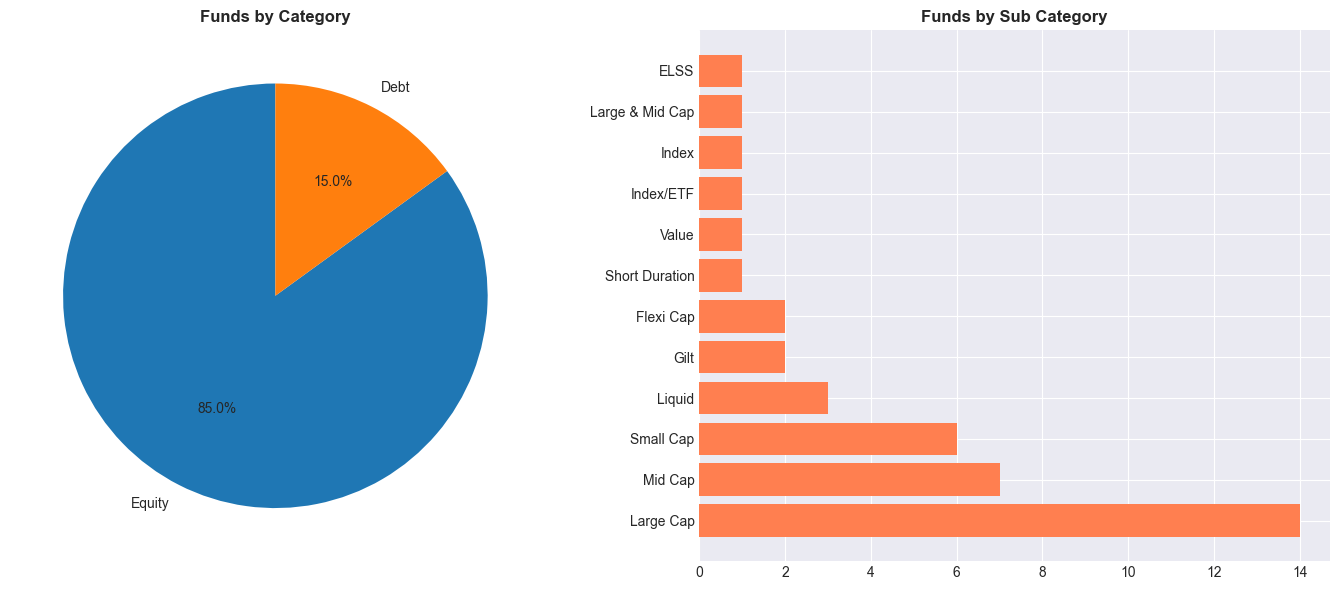

In [28]:
cat_count = funds['category'].value_counts()
sub_count = funds['sub_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(cat_count.values, labels=cat_count.index,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Funds by Category', fontweight='bold')

axes[1].barh(sub_count.index, sub_count.values, color='coral')
axes[1].set_title('Funds by Sub Category', fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS / "chart12_category_dist.png", dpi=150)
plt.show()

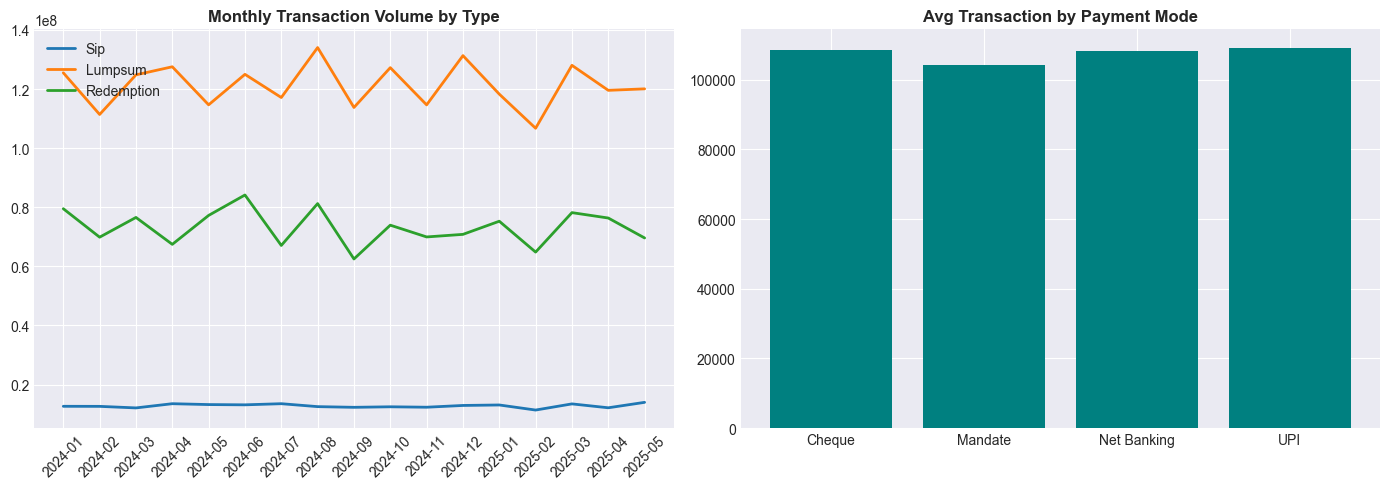

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly transaction volume
transactions['month'] = transactions['transaction_date'].dt.to_period('M')
monthly_tx = transactions.groupby(
    ['month','transaction_type'])['amount_inr'].sum().reset_index()
monthly_tx['month'] = monthly_tx['month'].astype(str)

for tx_type in ['Sip', 'Lumpsum', 'Redemption']:
    data = monthly_tx[monthly_tx['transaction_type']==tx_type]
    axes[0].plot(data['month'], data['amount_inr'],
                 label=tx_type, linewidth=2)

axes[0].set_title('Monthly Transaction Volume by Type',
                  fontweight='bold')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Average amount by payment mode
pay_avg = transactions.groupby('payment_mode')['amount_inr'].mean()
axes[1].bar(pay_avg.index, pay_avg.values, color='teal')
axes[1].set_title('Avg Transaction by Payment Mode',
                  fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS / "chart13_transactions.png", dpi=150)
plt.show()

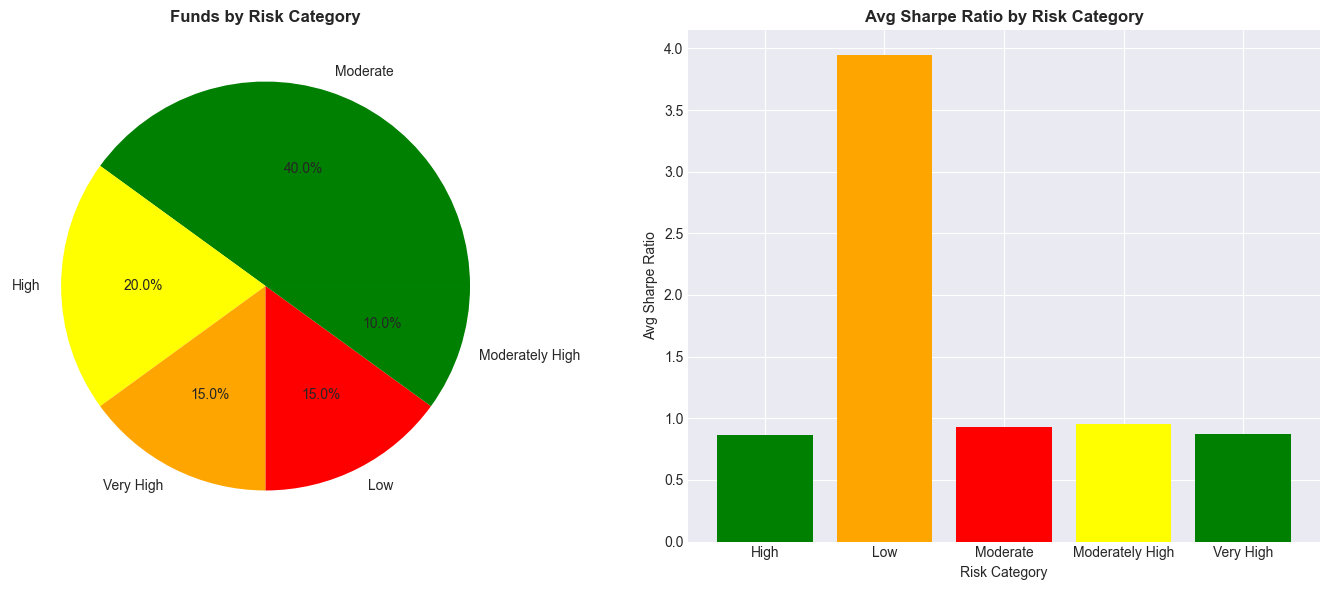

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Risk category distribution
risk_dist = funds['risk_category'].value_counts()
axes[0].pie(risk_dist.values, labels=risk_dist.index,
            autopct='%1.1f%%',
            colors=['green','yellow','orange','red'])
axes[0].set_title('Funds by Risk Category', fontweight='bold')

# Sharpe ratio by risk category
perf_risk = performance.merge(
    funds[['amfi_code','risk_category']], on='amfi_code')
risk_sharpe = perf_risk.groupby('risk_category')['sharpe_ratio'].mean()
axes[1].bar(risk_sharpe.index, risk_sharpe.values,
            color=['green','orange','red','yellow'])
axes[1].set_title('Avg Sharpe Ratio by Risk Category',
                  fontweight='bold')
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Avg Sharpe Ratio')

plt.tight_layout()
plt.savefig(REPORTS / "chart14_risk_analysis.png", dpi=150)
plt.show()

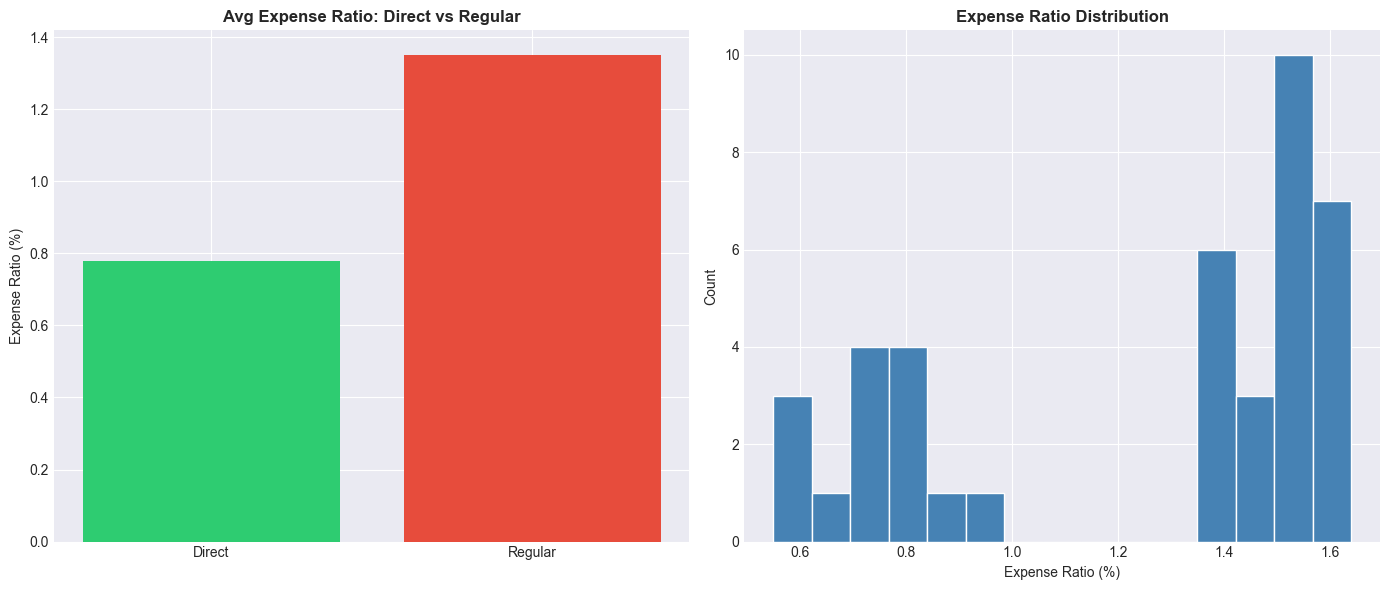

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Direct vs Regular expense ratio
plan_expense = funds.groupby('plan')['expense_ratio_pct'].mean()
axes[0].bar(plan_expense.index, plan_expense.values,
            color=['#2ecc71','#e74c3c'])
axes[0].set_title('Avg Expense Ratio: Direct vs Regular',
                  fontweight='bold')
axes[0].set_ylabel('Expense Ratio (%)')

# Expense ratio distribution
axes[1].hist(funds['expense_ratio_pct'], bins=15,
             color='steelblue', edgecolor='white')
axes[1].set_title('Expense Ratio Distribution',
                  fontweight='bold')
axes[1].set_xlabel('Expense Ratio (%)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(REPORTS / "chart15_expense_ratio.png", dpi=150)
plt.show()